In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tif
import skimage.filters as filt
import skimage.morphology as morph
import json
from matplotlib import cm
from matplotlib import colors
# %matplotlib widget

In [ ]:
def yellow_0_cmap(length=256, cmap='viridis'):
    """
    this function takes a given matplotlib colormap and sets the 0 value to black (RGBa)

    :param cmap: str. name of colormap to edit
    
    :return: listed colormap with 0 value set to black
    """
    oldcmap = cm.get_cmap(cmap)
    newcolors = oldcmap(np.linspace(0, 1, length))
    newcolors[0] = [1, 1, 0, 1]
    return colors.ListedColormap(newcolors)

newcm = yellow_0_cmap()

In [ ]:
# image_set = r'C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_images\20240708\FP_G13_binned_tiffs'
# im = tif.imread(image_set)
# tif.imwrite(r'C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_images\20240516\b2rgq_binned_tiffs\20240516_b2rgq_Measurement7a_set5.tiff', im[:, :, :320, :])
# tif.imwrite(r'C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_images\20240516\b2rgq_binned_tiffs\20240516_b2rgq_Measurement7b_set5.tiff', im[:, :, 320:, :])

# tif.imwrite(r'C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_images\20240517\at1rg13_binned_tiffs\20240517_at1rg13_measurement10a_set5.tiff', im[:, :100, :, :])
# tif.imwrite(r'C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_images\20240517\at1rg13_binned_tiffs\20240517_at1rg13_measurement10b_set5.tiff', im[:, 100:200, :, :])
# tif.imwrite(r'C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_images\20240516\b2rgq_binned_tiffs\20240516_b2rgq_Measurement8c_set5.tiff', im[:, 200:, :, :])

100


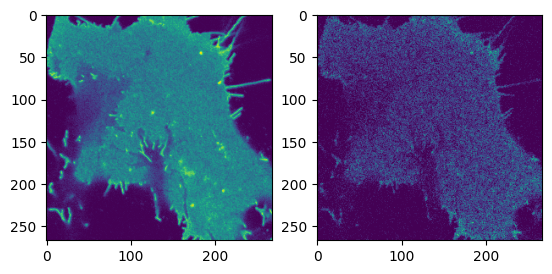

In [3203]:
image_set = r"C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\20250504\b2r_gq_binned_tiffs"
imname = r'\20250504_b2r_gq_measurement17c_set10.tiff'
image_set = image_set + imname
print(len(tif.imread(image_set)[1]))
plt.subplots(1, 2)
plt.subplot(1,2,1)
plt.imshow(tif.imread(image_set)[0, 0])
plt.subplot(1,2,2)
plt.imshow(tif.imread(image_set)[1, 0])
plt.show()

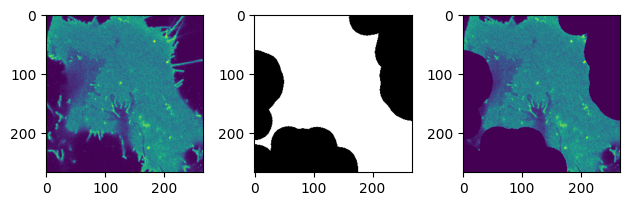

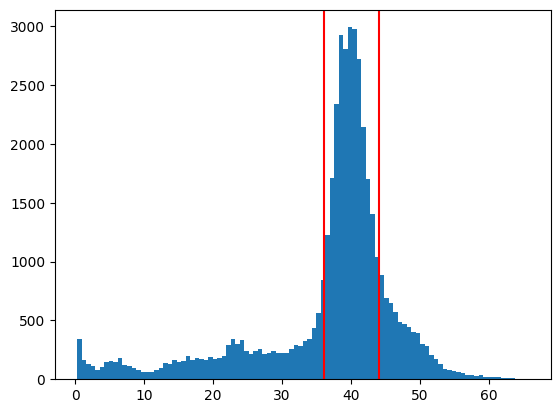

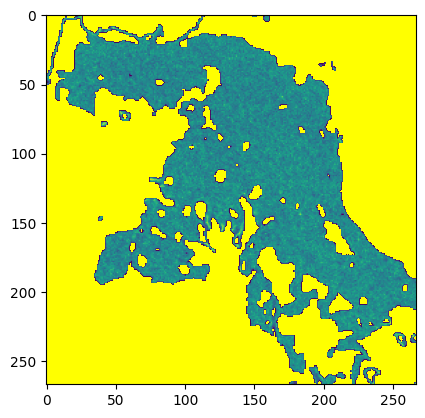

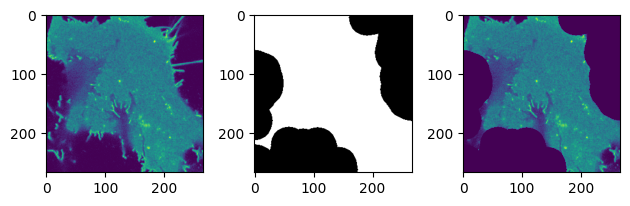

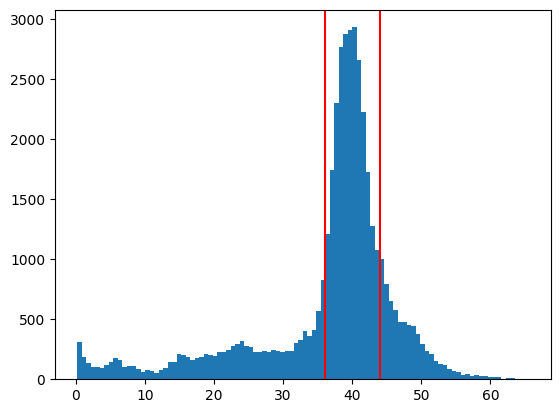

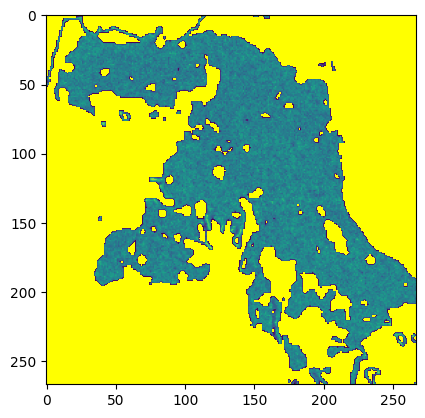

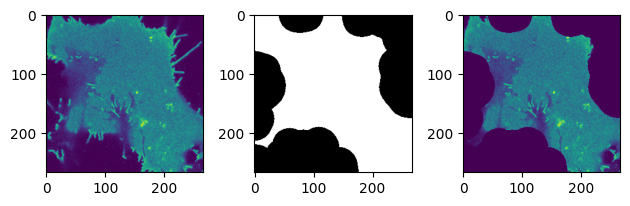

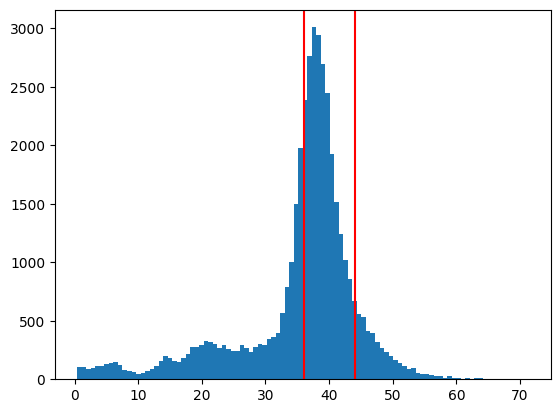

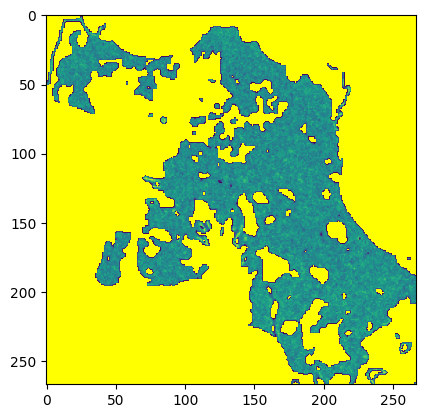

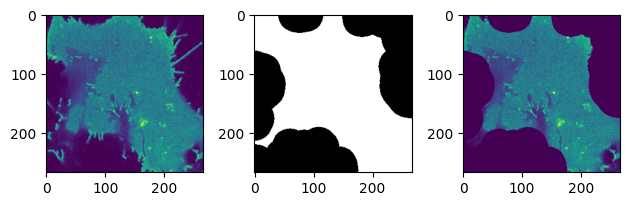

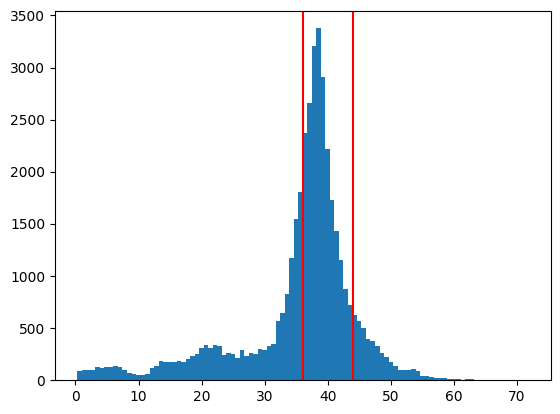

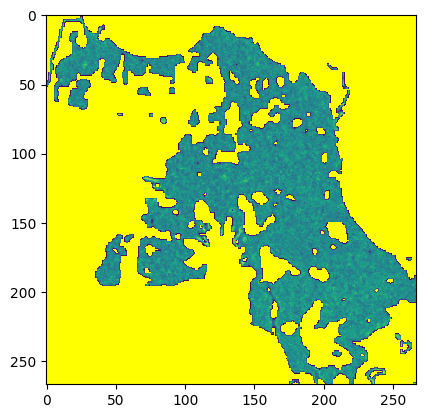

In [3206]:
# get intensity thresholds
# single color brightness fit channel 0
bminy=36
bmaxy=44

for i in range(4):
    idx = [0,1, -1, -2]
    im0 = tif.imread(image_set)[0, idx[i]]
    # plt.figure()
    # plt.imshow(im0, cmap='viridis')
    # plt.colorbar()
    # plt.show()

    disk = morph.disk(10)
    prepim = (im0 / np.max(im0) * 35).astype(np.uint8)
    res = filt.rank.entropy(prepim, disk)
    # plt.figure()
    # plt.imshow(res, cmap='viridis')
    # plt.colorbar()
    # plt.show()
    t = filt.threshold_otsu(res)
    # t = np.mean(res)
    fg = np.ones(im0.shape)
    fg[res < t] = 0
    fg = morph.binary_closing(fg, disk)
    fg = morph.binary_opening(fg, disk)


    # bgmap = -(fg -1)
    disk = morph.disk(20)
    fg = morph.binary_erosion(fg, disk)


    # see backgroung
    # d2 = morph.disk(20)
    # fg = morph.binary_dilation(fg, d2)
    # fg = -(fg - 1)
    # print(np.mean(im0[map == 1]))

    plt.figure()
    plt.subplot(131)
    plt.imshow(im0,)
    plt.subplot(132)
    plt.imshow(fg, 'gray')
    plt.subplot(133)
    segment = im0.copy()
    segment[fg==0] = 0
    plt.imshow(segment)
    plt.tight_layout()
    plt.show()

    blur2 = filt.gaussian(im0, sigma=2, truncate=6)
    blur2[fg==0] = 0 ### this is where I apply the segmentation map
    plt.figure()
    plt.hist(blur2[fg==1].ravel(), 100)
    plt.axvline(bminy, color='r')
    plt.axvline(bmaxy, color='r')
    plt.show()

    mapm = np.ones(im0.shape)
    mapm[blur2 <= bminy] = 0
    mapm[ blur2 > bmaxy] = 0

    # plt.figure()
    # plt.imshow(mapm)

    plt.figure()
    vis = im0.copy()
    vis[mapm==0]=0
    plt.imshow(vis, cmap=newcm)
    plt.show()

# nothing more

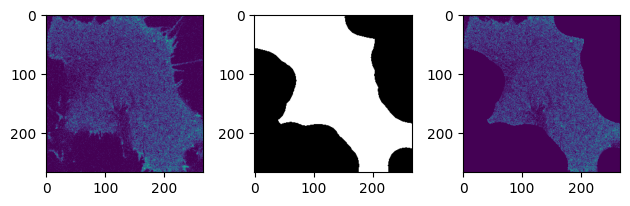

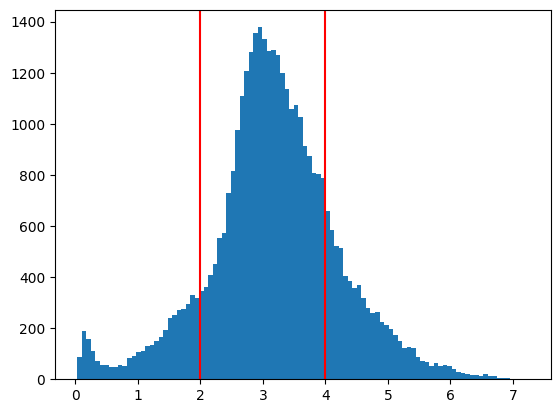

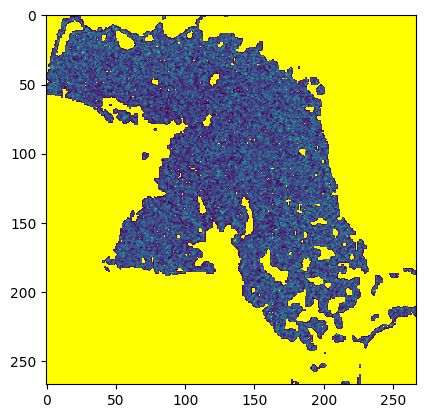

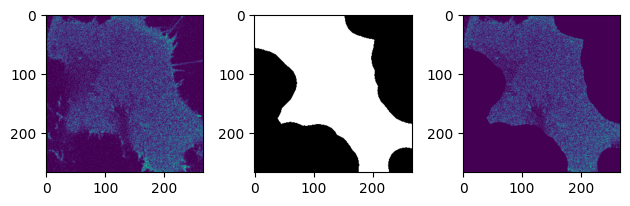

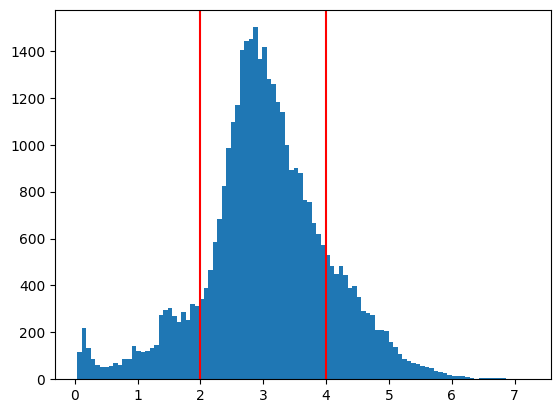

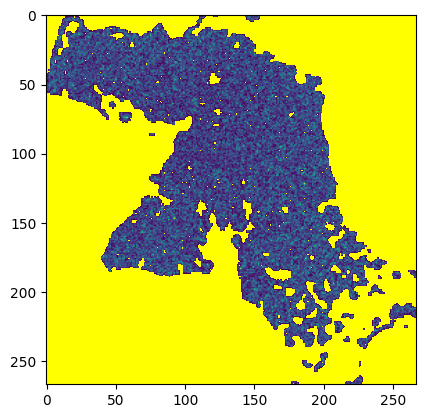

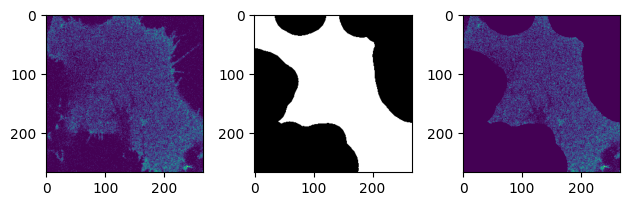

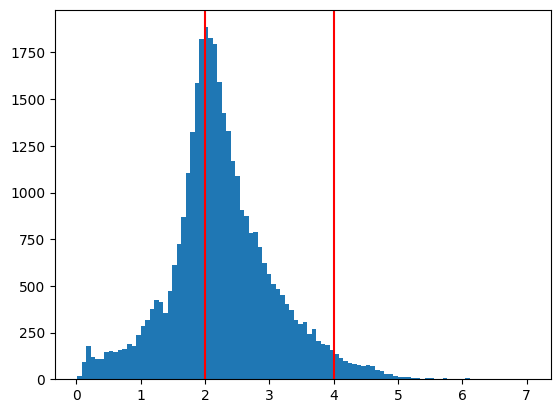

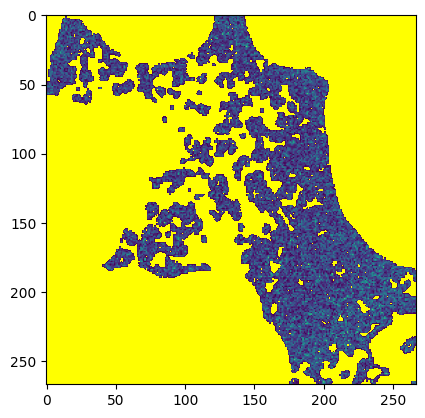

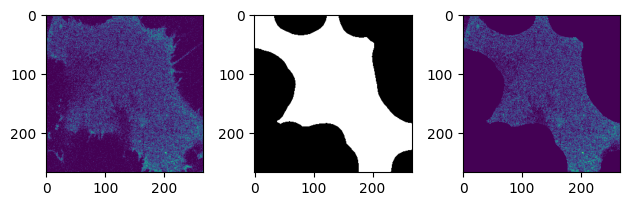

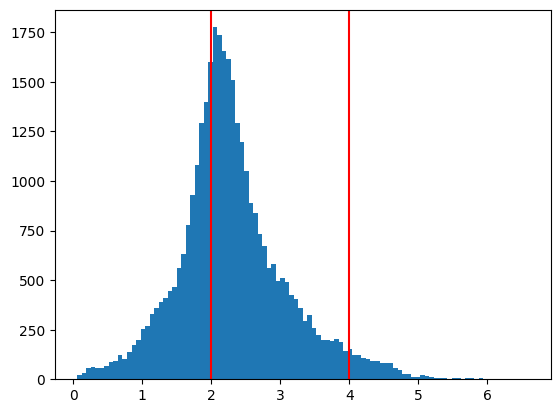

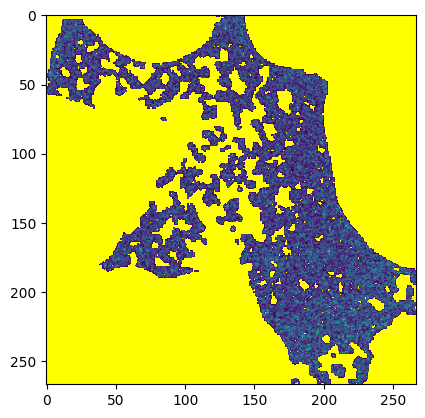

In [3208]:
# get intensity thresholds
# single color brightness fit channel 1
bminr=2
bmaxr=4

for i in range(4):
    idx = [0,1, -1, -2]
    im0 = tif.imread(image_set)[1, idx[i]]
    # plt.figure()
    # plt.imshow(im0, cmap='viridis')
    # plt.show()
    disk = morph.disk(10)
    prepim = (im0 / np.max(im0) * 35).astype(np.uint8)
    res = filt.rank.entropy(prepim, disk)
    t = filt.threshold_otsu(res)
    # t = np.mean(res)
    fg = np.ones(im0.shape)
    fg[res < t] = 0
    fg = morph.binary_closing(fg, disk)
    fg = morph.binary_opening(fg, disk)

    # bgmap = -(fg -1)

    disk = morph.disk(20)
    fg = morph.binary_erosion(fg, disk)


    # see backgroung
    # d2 = morph.disk(20)
    # map = morph.binary_dilation(map, d2)
    # map = -(map - 1)
    # print(np.mean(im0[map == 1]))

    plt.figure()
    plt.subplot(131)
    plt.imshow(im0,)
    plt.subplot(132)
    plt.imshow(fg, 'gray')
    plt.subplot(133)
    segment = im0.copy()
    segment[fg==0] = 0
    plt.imshow(segment)
    plt.tight_layout()
    plt.show()

    blur2 = filt.gaussian(im0, sigma=2, truncate=6)
    blur2[fg==0] = 0
    plt.figure()
    plt.hist(blur2[fg==1].ravel(), 100)
    plt.axvline(bminr, color='r')
    plt.axvline(bmaxr, color='r')
    plt.show()

    mapm = np.ones(im0.shape)
    mapm[blur2 <= bminr] = 0
    mapm[ blur2 > bmaxr] = 0
    
    plt.figure()
    vis = im0.copy()
    vis[ mapm == 0 ] = 0
    plt.imshow(vis, cmap=newcm)
    plt.show()

In [3209]:

map_params = {
    'image_stack':image_set,
    'yfp_min_blur':bminy,
    'yfp_max_blur':bmaxy,
    'mcherry_max_blur':bmaxr,
    'mcherry_min_blur':bminr,
    # 'use_red_map':True
    # 'use_yellow_map':True
}

param_loc = image_set[:-5] + '.json'
with open(param_loc, 'w') as f:
    json.dump(map_params, f)